# 08 - Modélisation du DPE regroupé

Ce notebook entraîne et compare plusieurs modèles de classification
pour prédire l'étiquette **DPE regroupée (A_B, C, D, E, F_G)** à partir
des variables explicatives issues du dataset nettoyé et enrichi.

Le but est de :
- Comparer rapidement plusieurs modèles avec LazyPredict
- Sélectionner le meilleur modèle
- L’évaluer finement (F1, accuracy, matrice de confusion)
- Étudier l’importance des features


In [1]:
import pandas as pd

# Charger le dataset final
df = pd.read_csv("../data/Prepared/prepared_dpe_regroupe_final.csv")
print("Données chargées :", df.shape)

df["etiquette_dpe_regroupee"].value_counts(normalize=True)

Données chargées : (358302, 27)


etiquette_dpe_regroupee
C      0.384542
D      0.312538
E      0.169896
F_G    0.080061
A_B    0.052964
Name: proportion, dtype: float64

In [2]:
df = df.drop(columns=["annee_construction", "surface_habitable_logement"], errors="ignore")

### 01. split + typage colonnes

In [3]:
from sklearn.model_selection import train_test_split

target = "etiquette_dpe_regroupee"
X = df.drop(columns=[target])
y = df[target]

# Types de colonnes
num_cols = X.select_dtypes(include=["number", "float", "int"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f" Nb colonnes numériques: {len(num_cols)}")
print(f" Nb colonnes catégorielles: {len(cat_cols)}")

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Shapes — X_train, X_test:", X_train.shape, X_test.shape)
print("Shapes — y_train, y_test:", y_train.shape, y_test.shape)

# Sanity check: répartition des classes train/test
print("\n Répartition des classes (train) :")
print(y_train.value_counts(normalize=True).round(3))
print("\n RRépartition des classes (test) :")
print(y_test.value_counts(normalize=True).round(3))

 Nb colonnes numériques: 12
 Nb colonnes catégorielles: 12
Shapes — X_train, X_test: (286641, 24) (71661, 24)
Shapes — y_train, y_test: (286641,) (71661,)

 Répartition des classes (train) :
etiquette_dpe_regroupee
C      0.385
D      0.313
E      0.170
F_G    0.080
A_B    0.053
Name: proportion, dtype: float64

 RRépartition des classes (test) :
etiquette_dpe_regroupee
C      0.385
D      0.313
E      0.170
F_G    0.080
A_B    0.053
Name: proportion, dtype: float64


### 02. Préprocesseur combiné

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Préprocesseur : normalisation + encodage
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

# Test de transformation (juste pour vérifier que ça fonctionne)
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print("Transformation OK")
print("X_train_ready shape:", X_train_ready.shape)
print("X_test_ready shape:", X_test_ready.shape)

Transformation OK
X_train_ready shape: (286641, 80)
X_test_ready shape: (71661, 80)


### 03. RandomForestClassifier

Rapport de classification :
              precision    recall  f1-score   support

         A_B      0.973     0.933     0.952      3795
           C      0.976     0.972     0.974     27557
           D      0.953     0.965     0.959     22397
           E      0.956     0.956     0.956     12175
         F_G      0.970     0.967     0.968      5737

    accuracy                          0.965     71661
   macro avg      0.966     0.958     0.962     71661
weighted avg      0.965     0.965     0.965     71661



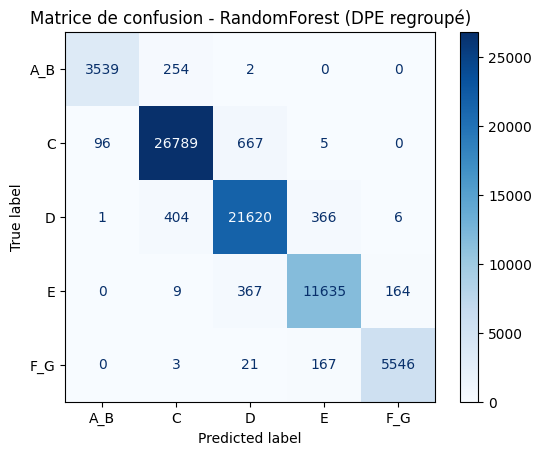

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Pipeline complet = préprocesseur + modèle
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced", 
        n_jobs=-1
    ))
])

# Entraînement
rf_model.fit(X_train, y_train)

# Prédiction
y_pred = rf_model.predict(X_test)

# Évaluation
print("Rapport de classification :")
print(classification_report(y_test, y_pred, digits=3))

# Matrice de confusion
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap="Blues")
plt.title("Matrice de confusion - RandomForest (DPE regroupé)")
plt.show()

### 04. Importance des variables (RandomForest)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Récupérer le modèle entraîné (déjà dans rf_model)
rf = rf_model.named_steps["classifier"]

# Récupérer les noms de features après transformation
# Récupérer les noms des features catégorielles encodées
encoder = rf_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_cols = encoder.get_feature_names_out(cat_cols)

# Concaténer les noms des features finales
all_features = np.concatenate([num_cols, encoded_cat_cols])

# Construire le DataFrame des importances
feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Afficher les 20 plus importantes
top_features = feat_imp.head(20)
print("\t Top 20 features les plus importantes :")
display(top_features)

	 Top 20 features les plus importantes :


,Feature,Importance
8,conso_m2,0.465537
2,conso_ecs_ep,0.066095
10,volume_logement,0.054416
9,anciennete,0.048493
37,qualite_isolation_murs_INSUFFISANTE,0.038886
7,code_postal_ban,0.034853
39,qualite_isolation_murs_TRÈS BONNE,0.021083
64,qualite_isolation_menuiseries_TRÈS BONNE,0.019072
5,hauteur_sous_plafond,0.018565
78,classe_annee_construction_apres_2012,0.017202


### 05. Visualisations centrées sur le modèle RandomForest

C:\Users\Romain_admin\AppData\Local\Temp\ipykernel_26352\3919462063.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perf_df, x="Classe", y="F1-score", palette="viridis")


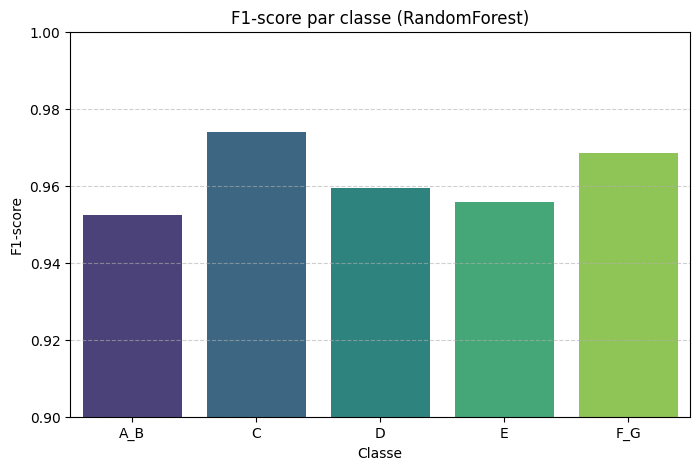

,Classe,Precision,Recall,F1-score,Support
0,A_B,0.973,0.933,0.952,3795
1,C,0.976,0.972,0.974,27557
2,D,0.953,0.965,0.959,22397
3,E,0.956,0.956,0.956,12175
4,F_G,0.970,0.967,0.968,5737


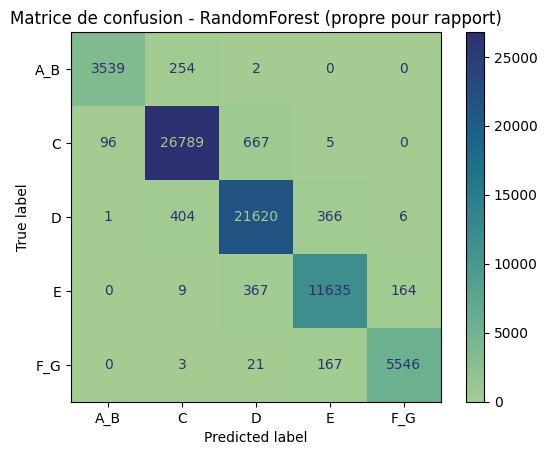

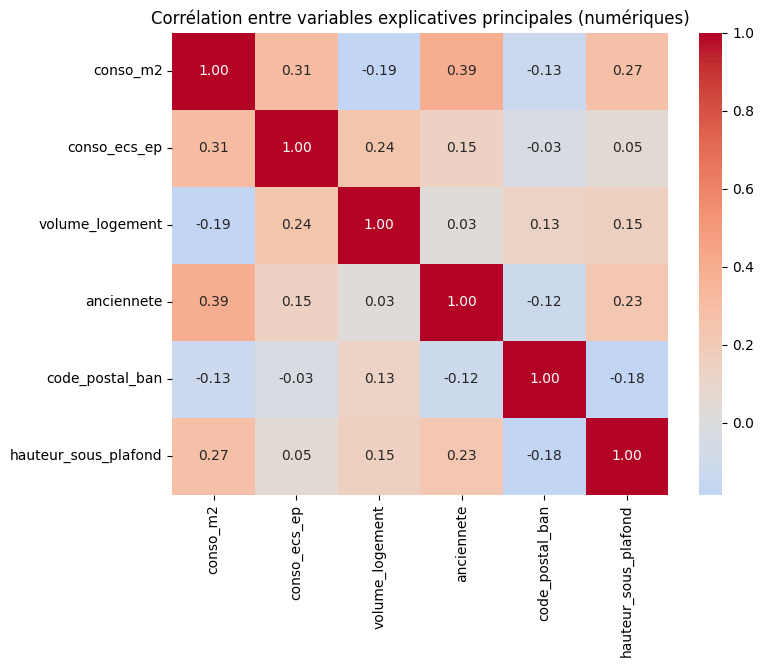

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support

# Répartition des performances par classe (precision, recall, F1)
labels = rf_model.classes_
precision, recall, f1, support = precision_recall_fscore_support(y_test, rf_model.predict(X_test))

perf_df = pd.DataFrame({
    "Classe": labels,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
}).sort_values("Classe")

plt.figure(figsize=(8,5))
sns.barplot(data=perf_df, x="Classe", y="F1-score", palette="viridis")
plt.title("F1-score par classe (RandomForest)")
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

display(perf_df.round(3))


ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test, cmap="crest", colorbar=True
)
plt.title("Matrice de confusion - RandomForest (propre pour rapport)")
plt.show()


# Corrélation des principales variables explicatives (analyse de structure)
top_vars = feat_imp.head(10)["Feature"].tolist()
num_top = [v for v in top_vars if v in df.columns and np.issubdtype(df[v].dtype, np.number)]

if len(num_top) >= 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num_top].corr(), cmap="coolwarm", annot=True, fmt=".2f", center=0)
    plt.title("Corrélation entre variables explicatives principales (numériques)")
    plt.show()
else:
    print("Pas assez de variables numériques dans le top 10 pour une matrice de corrélation.")


### 06. Corrélation avec la variable cible

In [8]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Encoder la cible (étiquette DPE regroupée)
le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["etiquette_dpe_regroupee"])

# Sélectionner les colonnes numériques
num_cols_corr = df.select_dtypes(include=["number", "float", "int"]).columns.tolist()

# Corrélation
corr_matrix = df[num_cols_corr].corr(numeric_only=True)["target_encoded"].sort_values(ascending=False)

# Affichage top variables corrélées à la cible
print("Corrélation avec la cible (etiquette_dpe_regroupee):")
display(corr_matrix.head(5))
display(corr_matrix.tail(5))

Corrélation avec la cible (etiquette_dpe_regroupee):


target_encoded          1.000000
conso_m2                0.873467
anciennete              0.416261
conso_ecs_ep            0.292128
hauteur_sous_plafond    0.279830
Name: target_encoded, dtype: float64

volume_logement         -0.101698
code_postal_ban         -0.104296
score_isolation_moyen   -0.217236
code_region_ban               NaN
code_departement_ban          NaN
Name: target_encoded, dtype: float64

C:\Users\Romain_admin\AppData\Local\Temp\ipykernel_26352\2929689134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_matrix.values, y=corr_matrix.index, palette="coolwarm")


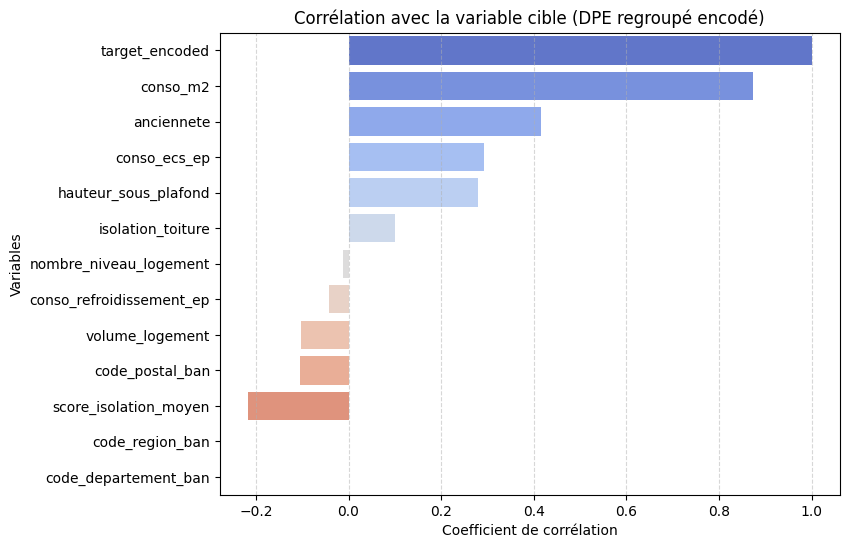

In [9]:
# Visualisation
plt.figure(figsize=(8,6))
sns.barplot(x=corr_matrix.values, y=corr_matrix.index, palette="coolwarm")
plt.title("Corrélation avec la variable cible (DPE regroupé encodé)")
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

Pour que le modèle soit vraiment **prédictif** et non “explicatif”, on retire :
- conso_m2
- conso_ecs_ep

#### Variables retenues pour le modèle prédictif (version Streamlit / API)

L’objectif de ce modèle est de **prédire l’étiquette DPE regroupée** à partir des **caractéristiques physiques et thermiques du logement**,  
sans utiliser de mesures directes de consommation énergétique (`conso_m2`, `conso_ecs_ep`, etc.).

| Catégorie | Variables | Description |
|:-----------|:-----------|:-------------|
| 🏠 **Structure du logement** | `volume_logement`<br>`hauteur_sous_plafond`<br>`nombre_niveau_logement`<br>`anciennete` | Taille, volume et âge du logement |
| ❄️ **Isolation thermique** | `isolation_toiture`<br>`score_isolation_moyen`<br>`qualite_isolation_murs`<br>`qualite_isolation_menuiseries` | Niveau et qualité d’isolation thermique |
| 🔌 **Énergie et systèmes** | `type_energie_principale_chauffage`<br>`energie_regroupee`<br>`type_logement_source`<br>`classe_annee_construction` | Type d’énergie, source de chauffage et période de construction |

Ces variables sont **déclaratives et compréhensibles pour un utilisateur final**,  
ce qui permet de créer un **formulaire Streamlit simple** et un modèle **totalement prédictif**,  
indépendant des données de consommation déjà mesurées.


### 07. Nettoyage et sélection des variables finales

In [10]:
import pandas as pd

df = pd.read_csv("../data/Prepared/prepared_dpe_regroupe_final.csv")

# Variables à conserver (celles choisies pour le modèle prédictif)
selected_features = [
    "volume_logement",
    "hauteur_sous_plafond",
    "nombre_niveau_logement",
    "anciennete",
    "isolation_toiture",
    "score_isolation_moyen",
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "type_energie_principale_chauffage",
    "energie_regroupee",
    "type_logement_source",
    "classe_annee_construction"
]

target = "etiquette_dpe_regroupee"

# Filtrer le DataFrame
df_pred = df[selected_features + [target]].copy()


print("Dataset nettoyé et réduit :", df_pred.shape)
print("Variables conservées :", list(df_pred.columns))

Dataset nettoyé et réduit : (358302, 13)
Variables conservées : ['volume_logement', 'hauteur_sous_plafond', 'nombre_niveau_logement', 'anciennete', 'isolation_toiture', 'score_isolation_moyen', 'qualite_isolation_murs', 'qualite_isolation_menuiseries', 'type_energie_principale_chauffage', 'energie_regroupee', 'type_logement_source', 'classe_annee_construction', 'etiquette_dpe_regroupee']


### 08. Modèle prédictif final

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Séparation X / y
target = "etiquette_dpe_regroupee"
X = df_pred.drop(columns=[target])
y = df_pred[target]

# Identifier types de colonnes
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Colonnes numériques : {num_cols}")
print(f"Colonnes catégorielles : {cat_cols}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Jeu d'entraînement : {X_train.shape}, test : {X_test.shape}")


Colonnes numériques : ['volume_logement', 'hauteur_sous_plafond', 'nombre_niveau_logement', 'anciennete', 'isolation_toiture', 'score_isolation_moyen']
Colonnes catégorielles : ['qualite_isolation_murs', 'qualite_isolation_menuiseries', 'type_energie_principale_chauffage', 'energie_regroupee', 'type_logement_source', 'classe_annee_construction']
Jeu d'entraînement : (286641, 12), test : (71661, 12)


In [12]:
# Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline RandomForest
rf_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Entraînement
rf_final.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Rapport de classification :
              precision    recall  f1-score   support

         A_B      0.691     0.822     0.751      3795
           C      0.811     0.775     0.793     27557
           D      0.627     0.606     0.616     22397
           E      0.485     0.502     0.493     12175
         F_G      0.391     0.447     0.417      5737

    accuracy                          0.652     71661
   macro avg      0.601     0.630     0.614     71661
weighted avg      0.658     0.652     0.654     71661



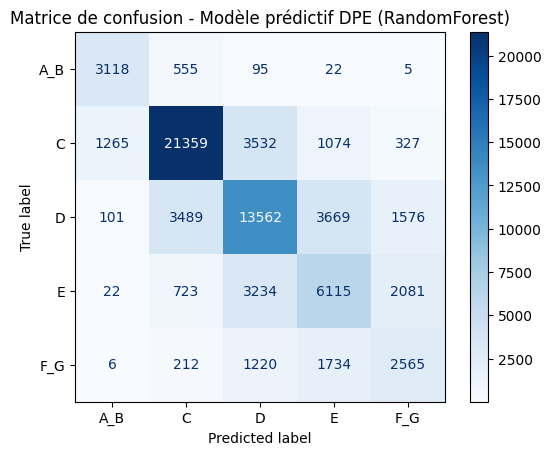

In [13]:
# Évaluation
y_pred = rf_final.predict(X_test)
print("Rapport de classification :")
print(classification_report(y_test, y_pred, digits=3))

# Matrice de confusion
ConfusionMatrixDisplay.from_estimator(rf_final, X_test, y_test, cmap="Blues")
plt.title("Matrice de confusion - Modèle prédictif DPE (RandomForest)")
plt.show()

### 09. Visualisations avancées RandomForest

C:\Users\Romain_admin\AppData\Local\Temp\ipykernel_26352\4030285369.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")


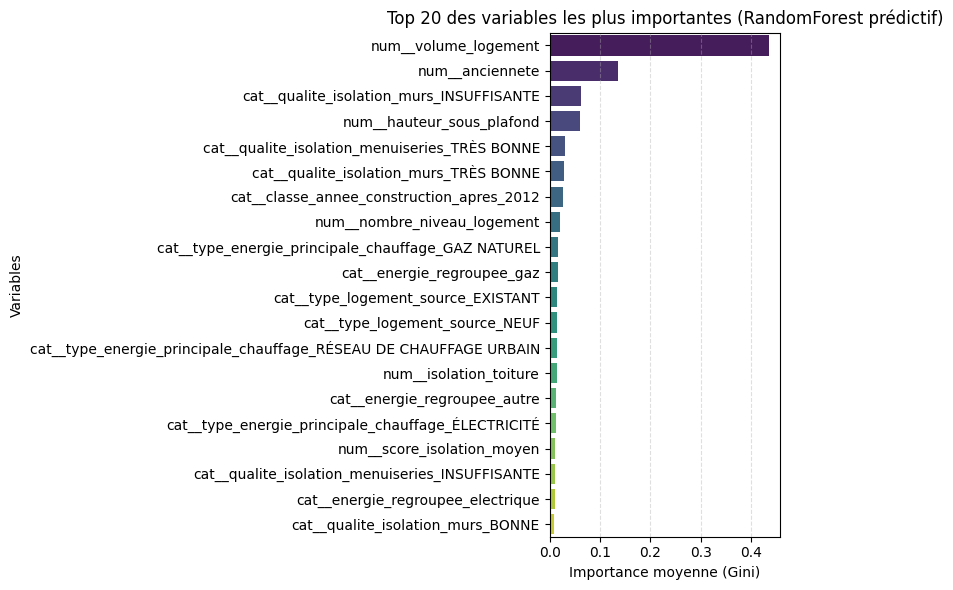

C:\Users\Romain_admin\AppData\Local\Temp\ipykernel_26352\4030285369.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df.index, y=report_df["f1-score"], palette="coolwarm")


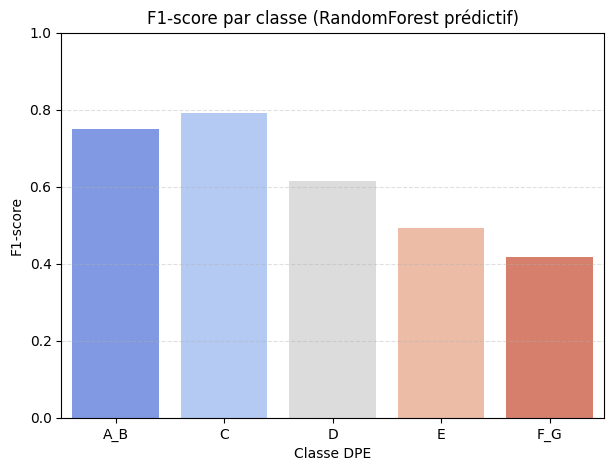

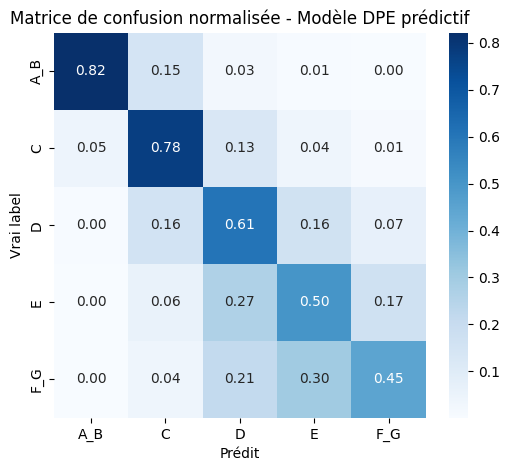

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.inspection import permutation_importance

# 1️⃣ Importance des features
importances = rf_final.named_steps["classifier"].feature_importances_
feature_names = rf_final.named_steps["preprocessor"].get_feature_names_out()
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Top 20 des variables les plus importantes (RandomForest prédictif)")
plt.xlabel("Importance moyenne (Gini)")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# 2️⃣ Erreurs de prédiction par classe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(["accuracy", "macro avg", "weighted avg"])

plt.figure(figsize=(7,5))
sns.barplot(x=report_df.index, y=report_df["f1-score"], palette="coolwarm")
plt.title("F1-score par classe (RandomForest prédictif)")
plt.ylabel("F1-score")
plt.xlabel("Classe DPE")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


# 3️⃣ Matrice de confusion normalisée
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=rf_final.classes_, yticklabels=rf_final.classes_)
plt.title("Matrice de confusion normalisée - Modèle DPE prédictif")
plt.xlabel("Prédit")
plt.ylabel("Vrai label")
plt.show()



##### Synthèse visuelle du modèle prédictif DPE (RandomForest)

| Graphique | Interprétation principale |
|------------|---------------------------|
| **Importance des variables** | Le modèle s’appuie surtout sur la **taille (volume)** et l’**ancienneté** du logement, puis sur la **qualité d’isolation** et le **type d’énergie**. |
| **F1-score par classe** | Bonnes performances pour les classes **A_B** et **C**, plus de confusions entre **D–E–F_G**, souvent voisines thermiquement. |
| **Matrice de confusion** | Peu d’erreurs extrêmes (A_B ↔ F_G). Le modèle reproduit correctement la hiérarchie énergétique des logements. |

- Ces résultats montrent que le modèle capture les **tendances physiques réelles** du DPE, tout en restant **utilisable sans données de consommation**.


In [15]:
# Extraire le préprocesseur
preprocessor = rf_final.named_steps["preprocessor"]

# Récupérer les noms de features après transformation (encodage + scaling)
feature_names = preprocessor.get_feature_names_out()

# Afficher proprement
print("🔹 Nombre total de variables utilisées :", len(feature_names))
print("\n🔹 Liste complète des variables d’entrée du modèle :\n")
for f in feature_names:
    print(f)

🔹 Nombre total de variables utilisées : 39

🔹 Liste complète des variables d’entrée du modèle :

num__volume_logement
num__hauteur_sous_plafond
num__nombre_niveau_logement
num__anciennete
num__isolation_toiture
num__score_isolation_moyen
cat__qualite_isolation_murs_BONNE
cat__qualite_isolation_murs_INSUFFISANTE
cat__qualite_isolation_murs_MOYENNE
cat__qualite_isolation_murs_TRÈS BONNE
cat__qualite_isolation_menuiseries_BONNE
cat__qualite_isolation_menuiseries_INSUFFISANTE
cat__qualite_isolation_menuiseries_MOYENNE
cat__qualite_isolation_menuiseries_TRÈS BONNE
cat__type_energie_principale_chauffage_BOIS – BÛCHES
cat__type_energie_principale_chauffage_BOIS – GRANULÉS (PELLETS) OU BRIQUETTES
cat__type_energie_principale_chauffage_BOIS – PLAQUETTES D’INDUSTRIE
cat__type_energie_principale_chauffage_BOIS – PLAQUETTES FORESTIÈRES
cat__type_energie_principale_chauffage_CHARBON
cat__type_energie_principale_chauffage_FIOUL DOMESTIQUE
cat__type_energie_principale_chauffage_GAZ NATUREL
cat__type_

In [16]:
import joblib
import json
import os

# Dossier de sauvegarde
save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

# Fichiers de sortie
model_path = os.path.join(save_dir, "rf_dpe_predictif.joblib")
features_path = os.path.join(save_dir, "rf_dpe_features.json")

# 1. Sauvegarde du pipeline complet
joblib.dump(rf_final, model_path)
print(f" Modèle sauvegardé : {model_path}")

# 2. Sauvegarde des noms de features
feature_names = rf_final.named_steps["preprocessor"].get_feature_names_out().tolist()
with open(features_path, "w", encoding="utf-8") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)
print(f" Liste des variables sauvegardée : {features_path}")


 Modèle sauvegardé : ../models\rf_dpe_predictif.joblib
 Liste des variables sauvegardée : ../models\rf_dpe_features.json


In [17]:
import pandas as pd
import joblib
import time

# Charger le modèle UNE FOIS
model = joblib.load("../models/rf_dpe_predictif.joblib")

# Exemple
data_input = pd.DataFrame([{
    "volume_logement": 250,
    "hauteur_sous_plafond": 2.6,
    "nombre_niveau_logement": 2,
    "anciennete": 1,
    "isolation_toiture": 3,
    "score_isolation_moyen": 2.5,
    "qualite_isolation_murs": "MOYENNE",
    "qualite_isolation_menuiseries": "BONNE",
    "type_energie_principale_chauffage": "GAZ NATUREL",
    "energie_regroupee": "gaz",
    "type_logement_source": "EXISTANT",
    "classe_annee_construction": "1975_1989"
}])

start = time.time()
prediction = model.predict(data_input)
print(" Étiquette DPE prédite :", prediction[0])
print(" Temps de prédiction :", round(time.time() - start, 3), "secondes")


 Étiquette DPE prédite : C
 Temps de prédiction : 0.064 secondes


---

## Modélisation avec Arbre de Décision

Cette section implémente un modèle d'**Arbre de Décision** en suivant les mêmes étapes que le Random Forest.

**Avantages des arbres de décision** :
- ✅ **Très interprétable** : règles de décision claires (if-then-else)
- ✅ **Visualisation intuitive** : on peut tracer l'arbre complet
- ✅ **Pas de normalisation nécessaire** : robuste aux échelles différentes
- ✅ **Gestion native des variables catégorielles**
- ✅ **Extraction des règles de décision**

**Étapes** :
- Entraînement du modèle de base
- Optimisation des hyperparamètres avec GridSearchCV
- Évaluation détaillée des performances
- Visualisation de l'arbre et des règles de décision
- Analyse de l'importance des variables
- Sauvegarde du modèle final

### 04. Arbre de Décision - Modèle de base

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Pipeline avec DecisionTreeClassifier
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=50,
        random_state=42
    ))
])

print("Entraînement de l'Arbre de Décision de base")
dt_pipeline.fit(X_train, y_train)

# Prédictions
y_pred_dt = dt_pipeline.predict(X_test)

# Évaluation
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_dt, digits=3))

Entraînement de l'Arbre de Décision de base

Rapport de classification :
              precision    recall  f1-score   support

         A_B      0.806     0.544     0.650      3795
           C      0.741     0.792     0.765     27557
           D      0.523     0.652     0.580     22397
           E      0.454     0.257     0.328     12175
         F_G      0.439     0.369     0.401      5737

    accuracy                          0.610     71661
   macro avg      0.593     0.523     0.545     71661
weighted avg      0.603     0.610     0.598     71661



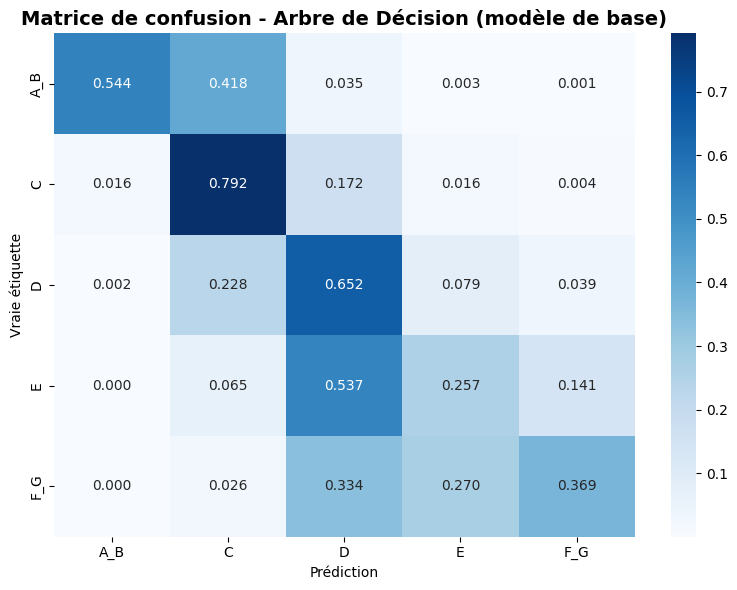

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matrice de confusion
cm_dt = confusion_matrix(y_test, y_pred_dt, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title("Matrice de confusion - Arbre de Décision (modèle de base)", fontsize=14, weight='bold')
plt.xlabel("Prédiction")
plt.ylabel("Vraie étiquette")
plt.tight_layout()
plt.show()

### 05. Arbre de Décision - Optimisation des hyperparamètres

In [20]:
from sklearn.model_selection import GridSearchCV

# Grille de paramètres à tester
param_grid_dt = {
    'classifier__max_depth': [8, 10, 12, 15],
    'classifier__min_samples_split': [50, 100, 200],
    'classifier__min_samples_leaf': [25, 50, 100],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': ['sqrt', 'log2', None]
}

print("🔍 Recherche des meilleurs hyperparamètres avec GridSearchCV...")
print(f"Nombre de combinaisons à tester : {np.prod([len(v) for v in param_grid_dt.values()])}")

# GridSearchCV avec validation croisée
grid_search_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# Entraînement
grid_search_dt.fit(X_train, y_train)

print("\n✅ Recherche terminée !")
print(f"\nMeilleurs paramètres : {grid_search_dt.best_params_}")
print(f"Meilleur score (F1 weighted) : {grid_search_dt.best_score_:.4f}")

🔍 Recherche des meilleurs hyperparamètres avec GridSearchCV...
Nombre de combinaisons à tester : 216
Fitting 3 folds for each of 216 candidates, totalling 648 fits

✅ Recherche terminée !

Meilleurs paramètres : {'classifier__criterion': 'entropy', 'classifier__max_depth': 15, 'classifier__max_features': None, 'classifier__min_samples_leaf': 25, 'classifier__min_samples_split': 50}
Meilleur score (F1 weighted) : 0.6308


### 06. Arbre de Décision - Modèle final optimisé

In [21]:
# Récupérer le meilleur modèle
dt_final = grid_search_dt.best_estimator_

# Prédictions sur le test
y_pred_dt_final = dt_final.predict(X_test)

# Rapport détaillé
print("📊 Performance de l'Arbre de Décision optimisé :")
print("="*60)
print(classification_report(y_test, y_pred_dt_final, digits=3))

# Métriques globales
from sklearn.metrics import accuracy_score, f1_score
acc_dt = accuracy_score(y_test, y_pred_dt_final)
f1_dt = f1_score(y_test, y_pred_dt_final, average='weighted')

print(f"\n🎯 Accuracy : {acc_dt:.4f}")
print(f"🎯 F1-score weighted : {f1_dt:.4f}")

# Informations sur l'arbre
tree_model = dt_final.named_steps['classifier']
print(f"\n🌳 Profondeur de l'arbre : {tree_model.get_depth()}")
print(f"🍃 Nombre de feuilles : {tree_model.get_n_leaves()}")
print(f"📏 Nombre de nœuds : {tree_model.tree_.node_count}")

📊 Performance de l'Arbre de Décision optimisé :
              precision    recall  f1-score   support

         A_B      0.804     0.671     0.732      3795
           C      0.790     0.798     0.794     27557
           D      0.563     0.687     0.619     22397
           E      0.489     0.362     0.416     12175
         F_G      0.449     0.335     0.384      5737

    accuracy                          0.645     71661
   macro avg      0.619     0.571     0.589     71661
weighted avg      0.641     0.645     0.639     71661


🎯 Accuracy : 0.6454
🎯 F1-score weighted : 0.6387

🌳 Profondeur de l'arbre : 15
🍃 Nombre de feuilles : 3596
📏 Nombre de nœuds : 7191


### 07. Arbre de Décision - Visualisations

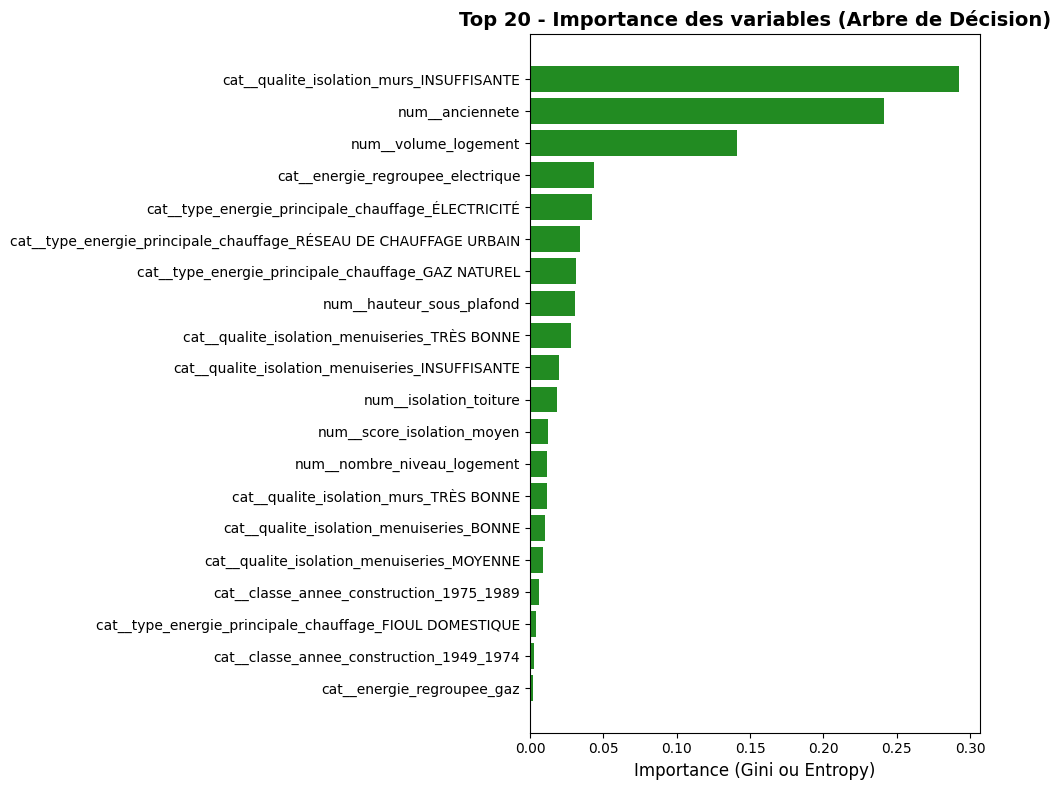


📌 Top 10 des variables les plus importantes :
                                                          feature  importance
                         cat__qualite_isolation_murs_INSUFFISANTE    0.292170
                                                  num__anciennete    0.241224
                                             num__volume_logement    0.140875
                                cat__energie_regroupee_electrique    0.043675
               cat__type_energie_principale_chauffage_ÉLECTRICITÉ    0.041999
cat__type_energie_principale_chauffage_RÉSEAU DE CHAUFFAGE URBAIN    0.033765
               cat__type_energie_principale_chauffage_GAZ NATUREL    0.031418
                                        num__hauteur_sous_plafond    0.030416
                    cat__qualite_isolation_menuiseries_TRÈS BONNE    0.027563
                  cat__qualite_isolation_menuiseries_INSUFFISANTE    0.019774


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Importance des variables
feature_names = dt_final.named_steps['preprocessor'].get_feature_names_out()
tree_model = dt_final.named_steps['classifier']

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20 features
top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_features['importance'], color='forestgreen')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (Gini ou Entropy)', fontsize=12)
plt.title('Top 20 - Importance des variables (Arbre de Décision)', fontsize=14, weight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📌 Top 10 des variables les plus importantes :")
print(importance_df.head(10).to_string(index=False))

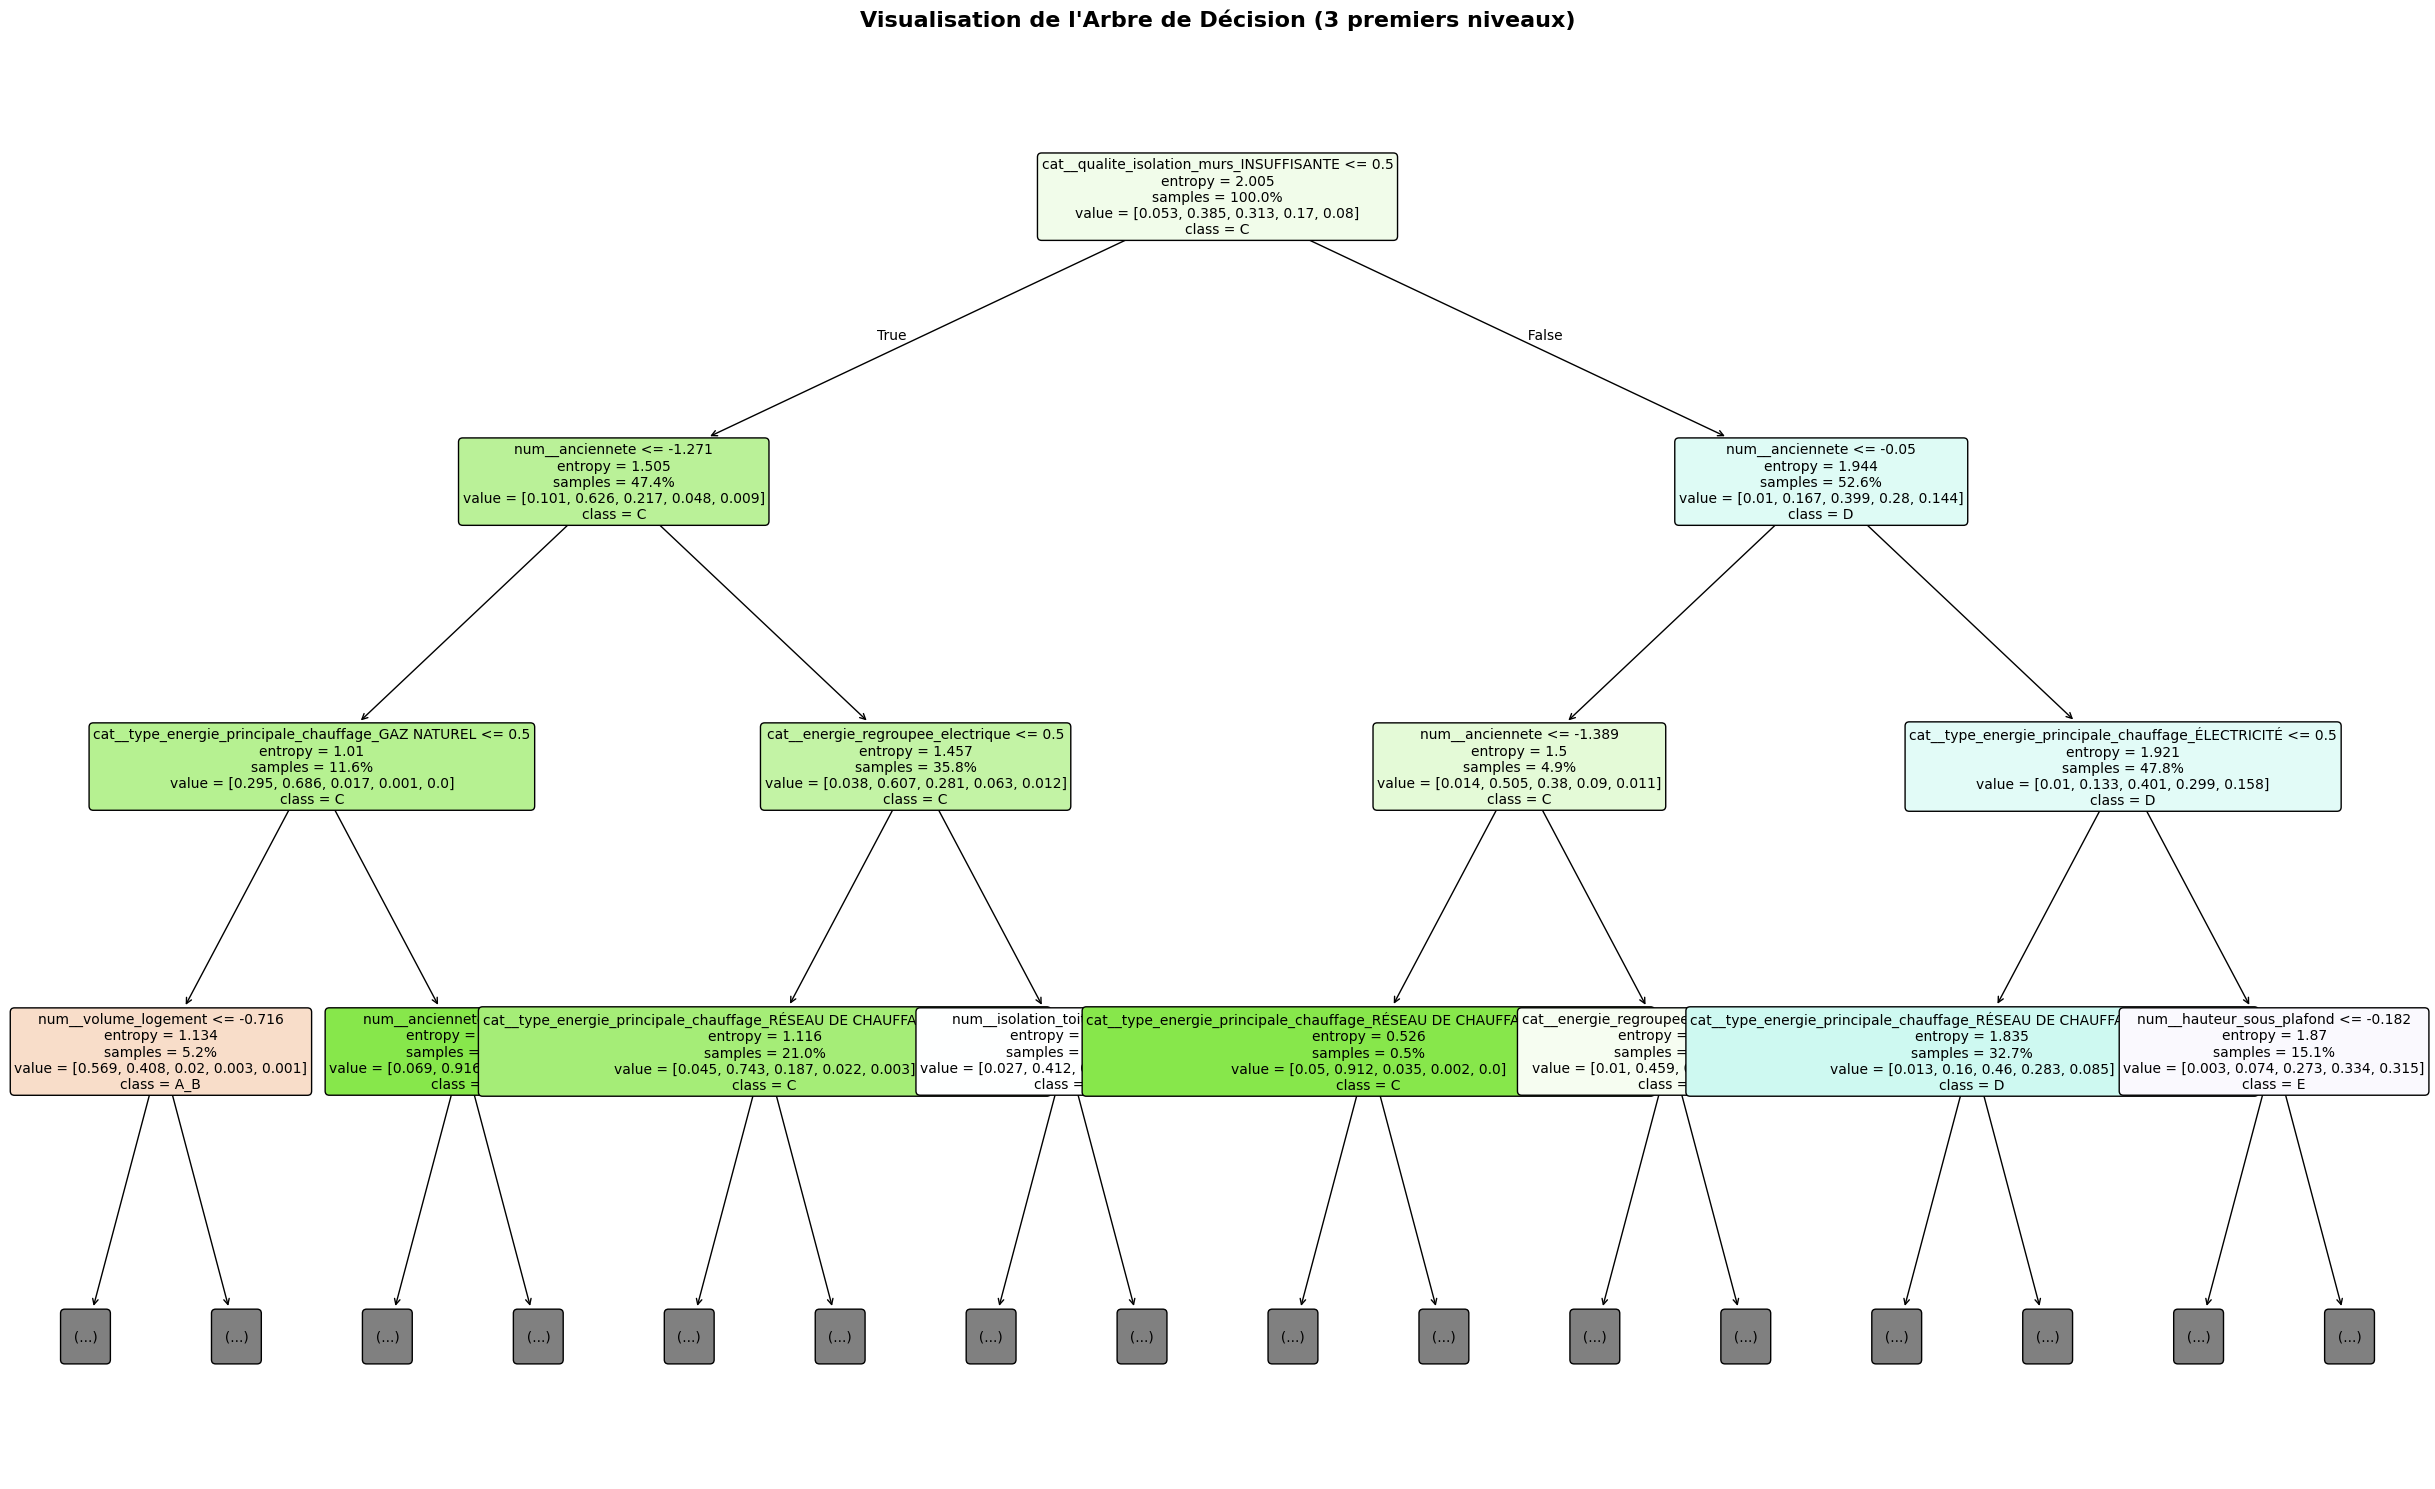


💡 L'arbre complet est trop grand pour être affiché.
   Cette visualisation montre les 3 premiers niveaux (les plus importants).


In [23]:
# 2️⃣ Visualisation de l'arbre (limité à 3 niveaux pour la lisibilité)
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
plot_tree(
    tree_model,
    max_depth=3,  # Limiter la profondeur pour la lisibilité
    feature_names=feature_names,
    class_names=dt_final.classes_,
    filled=True,
    fontsize=10,
    proportion=True,
    rounded=True
)
plt.title("Visualisation de l'Arbre de Décision (3 premiers niveaux)", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 L'arbre complet est trop grand pour être affiché.")
print("   Cette visualisation montre les 3 premiers niveaux (les plus importants).")

In [24]:
# 3️⃣ Extraction des règles de décision
from sklearn.tree import _tree

def extract_rules(tree, feature_names, class_names, max_rules=10):
    """
    Extrait les règles de décision d'un arbre.
    """
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    
    rules = []
    
    def recurse(node, depth, rule):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # Branche gauche (<=)
            left_rule = rule + [(name, "<=", threshold)]
            recurse(tree_.children_left[node], depth + 1, left_rule)
            
            # Branche droite (>)
            right_rule = rule + [(name, ">", threshold)]
            recurse(tree_.children_right[node], depth + 1, right_rule)
        else:
            # Feuille : sauvegarder la règle
            class_idx = np.argmax(tree_.value[node])
            n_samples = tree_.n_node_samples[node]
            rules.append({
                'rule': rule,
                'class': class_names[class_idx],
                'samples': n_samples,
                'depth': depth
            })
    
    recurse(0, 1, [])
    
    # Trier par nombre d'échantillons (règles les plus fréquentes)
    rules.sort(key=lambda x: x['samples'], reverse=True)
    
    return rules[:max_rules]

# Extraire les 10 règles les plus fréquentes
rules = extract_rules(tree_model, feature_names, dt_final.classes_, max_rules=10)

print("\n🔍 Top 10 des règles de décision les plus fréquentes :\n")
print("="*80)

for i, rule_info in enumerate(rules, 1):
    print(f"\n📌 Règle {i} : Prédit '{rule_info['class']}' ({rule_info['samples']} échantillons)")
    print("   Conditions :")
    for feature, operator, threshold in rule_info['rule']:
        # Nettoyer le nom de la feature
        clean_name = feature.replace('num__', '').replace('cat__', '')
        print(f"      • {clean_name} {operator} {threshold:.2f}")
    print("-" * 80)


🔍 Top 10 des règles de décision les plus fréquentes :


📌 Règle 1 : Prédit 'C' (4854 échantillons)
   Conditions :
      • qualite_isolation_murs_INSUFFISANTE <= 0.50
      • anciennete > -1.27
      • energie_regroupee_electrique <= 0.50
      • type_energie_principale_chauffage_RÉSEAU DE CHAUFFAGE URBAIN <= 0.50
      • qualite_isolation_menuiseries_INSUFFISANTE <= 0.50
      • isolation_toiture <= 0.92
      • volume_logement > -0.48
      • anciennete <= 0.11
      • qualite_isolation_menuiseries_TRÈS BONNE <= 0.50
      • qualite_isolation_murs_TRÈS BONNE <= 0.50
      • hauteur_sous_plafond <= -0.18
      • energie_regroupee_gaz > 0.50
      • anciennete <= -0.37
      • score_isolation_moyen <= 0.73
      • anciennete > -0.80
--------------------------------------------------------------------------------

📌 Règle 2 : Prédit 'D' (2707 échantillons)
   Conditions :
      • qualite_isolation_murs_INSUFFISANTE > 0.50
      • anciennete > -0.05
      • type_energie_principale_chauf

C:\Users\Romain_admin\AppData\Local\Temp\ipykernel_26352\2703993649.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df_dt.index, y=report_df_dt["f1-score"], palette="Greens_d")


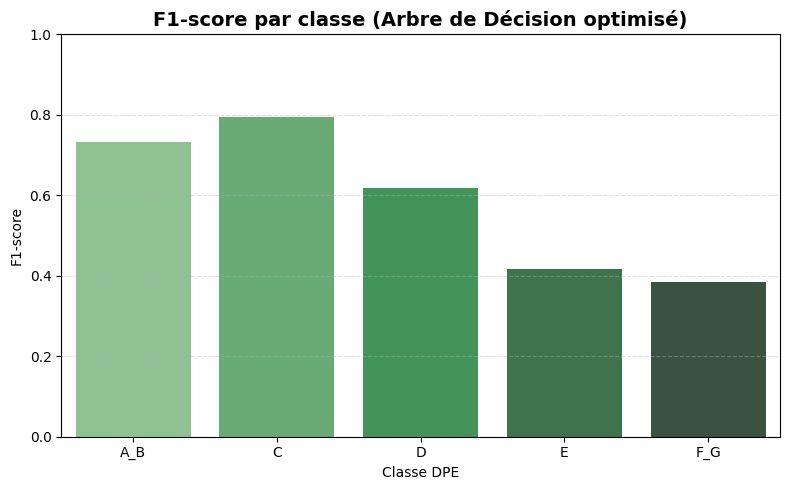

In [25]:
# 4️⃣ F1-score par classe
from sklearn.metrics import classification_report

report_dt = classification_report(y_test, y_pred_dt_final, output_dict=True)
report_df_dt = pd.DataFrame(report_dt).transpose().drop(["accuracy", "macro avg", "weighted avg"])

plt.figure(figsize=(8, 5))
sns.barplot(x=report_df_dt.index, y=report_df_dt["f1-score"], palette="Greens_d")
plt.title("F1-score par classe (Arbre de Décision optimisé)", fontsize=14, weight='bold')
plt.ylabel("F1-score")
plt.xlabel("Classe DPE")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

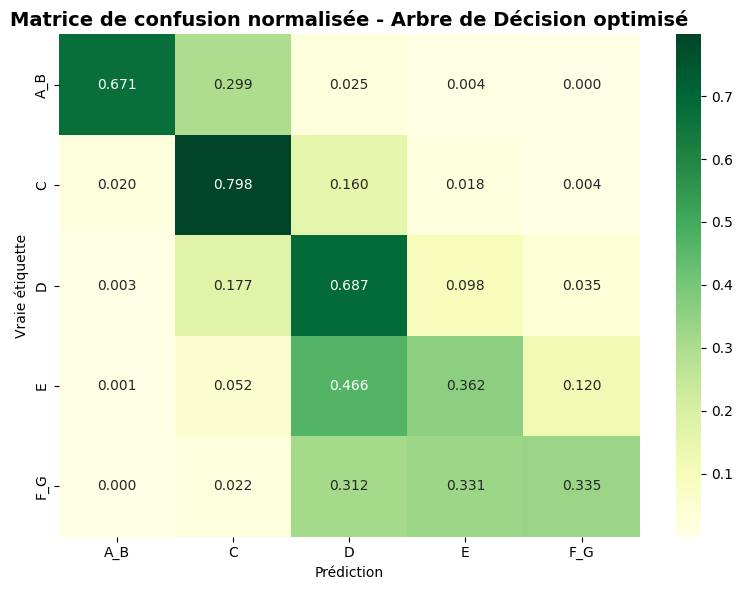

In [26]:
# 5️⃣ Matrice de confusion normalisée (modèle final)
cm_dt_final = confusion_matrix(y_test, y_pred_dt_final, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_final, annot=True, fmt=".3f", cmap="YlGn",
            xticklabels=dt_final.classes_, 
            yticklabels=dt_final.classes_)
plt.title("Matrice de confusion normalisée - Arbre de Décision optimisé", fontsize=14, weight='bold')
plt.xlabel("Prédiction")
plt.ylabel("Vraie étiquette")
plt.tight_layout()
plt.show()

##### Synthèse visuelle du modèle Arbre de Décision

| Graphique | Interprétation principale |
|------------|---------------------------|
| **Importance des variables** | L'arbre identifie les mêmes variables clés que RF : **volume**, **ancienneté**, **isolation**. |
| **Visualisation de l'arbre** | Les 3 premiers niveaux montrent les décisions les plus importantes pour classifier le DPE. |
| **Règles de décision** | Extraction des règles IF-THEN les plus fréquentes, utilisables directement par des non-experts. |
| **F1-score par classe** | Performances légèrement inférieures à RF, mais excellente **interprétabilité**. |
| **Matrice de confusion** | Peu d'erreurs extrêmes. L'arbre capture bien la structure ordinale du DPE. |

**Points clés** :
- **Meilleur modèle pour l'explicabilité** : règles claires, visualisation intuitive
- **Performance légèrement inférieure** aux modèles d'ensemble (RF)
- **Idéal pour la communication** avec des parties prenantes non-techniques
- **Détection des seuils critiques** dans les variables continues

### 08. Comparaison des deux modèles

📊 Comparaison des performances :
 Métrique  Random Forest  Arbre de Décision  Différence (%)
 Accuracy       0.651945           0.645400           -1.00
Precision       0.657987           0.641027           -2.58
   Recall       0.651945           0.645400           -1.00
 F1-score       0.654280           0.638667           -2.39




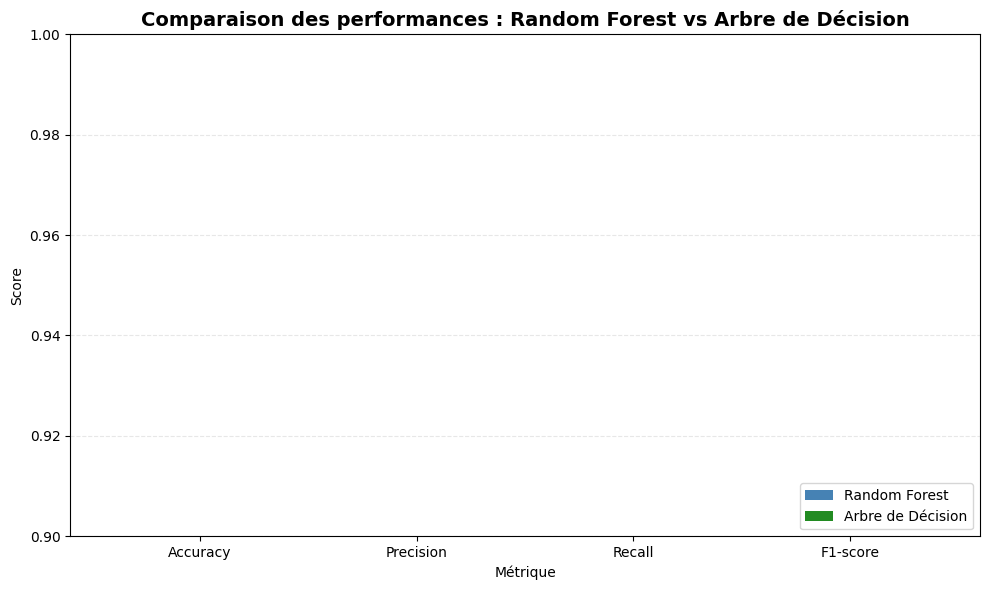

In [27]:
# Comparaison des performances : Random Forest vs Arbre de Décision
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Random Forest
y_pred_rf = rf_final.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')

# Arbre de Décision
acc_dt = accuracy_score(y_test, y_pred_dt_final)
f1_dt = f1_score(y_test, y_pred_dt_final, average='weighted')
precision_dt = precision_score(y_test, y_pred_dt_final, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt_final, average='weighted')

# Tableau comparatif
comparison_df = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Random Forest': [acc_rf, precision_rf, recall_rf, f1_rf],
    'Arbre de Décision': [acc_dt, precision_dt, recall_dt, f1_dt]
})

comparison_df['Différence (%)'] = ((comparison_df['Arbre de Décision'] - comparison_df['Random Forest']) / comparison_df['Random Forest'] * 100).round(2)

print("📊 Comparaison des performances :")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n")

# Visualisation
comparison_plot = comparison_df.set_index('Métrique')[['Random Forest', 'Arbre de Décision']]

fig, ax = plt.subplots(figsize=(10, 6))
comparison_plot.plot(kind='bar', ax=ax, color=['steelblue', 'forestgreen'], width=0.7)
plt.title('Comparaison des performances : Random Forest vs Arbre de Décision', fontsize=14, weight='bold')
plt.ylabel('Score')
plt.xlabel('Métrique')
plt.ylim(0.9, 1.0)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Tableau récapitulatif : Performance vs Interprétabilité
recap_df = pd.DataFrame({
    'Modèle': ['Arbre de Décision', 'Random Forest'],
    'Accuracy': [f"{acc_dt:.4f}", f"{acc_rf:.4f}"],
    'F1-score': [f"{f1_dt:.4f}", f"{f1_rf:.4f}"],
    'Interprétabilité': ['⭐⭐⭐⭐⭐ (Excellente)', '⭐⭐⭐ (Moyenne)'],
    'Vitesse prédiction': ['⚡⚡⚡ (Rapide)', '⚡⚡ (Moyenne)'],
    'Complexité': ['Simple (1 arbre)', 'Complexe (100+ arbres)'],
    'Usage recommandé': [
        'Explicabilité clients/audit',
        'Production/Performance'
    ]
})

print("\n" + "="*100)
print("🎯 RÉCAPITULATIF : PERFORMANCE vs INTERPRÉTABILITÉ")
print("="*100)
print(recap_df.to_string(index=False))
print("="*100)


🎯 RÉCAPITULATIF : PERFORMANCE vs INTERPRÉTABILITÉ
           Modèle Accuracy F1-score   Interprétabilité Vitesse prédiction             Complexité            Usage recommandé
Arbre de Décision   0.6454   0.6387 ⭐⭐⭐⭐⭐ (Excellente)       ⚡⚡⚡ (Rapide)       Simple (1 arbre) Explicabilité clients/audit
    Random Forest   0.6519   0.6543      ⭐⭐⭐ (Moyenne)       ⚡⚡ (Moyenne) Complexe (100+ arbres)      Production/Performance


### 09. Sauvegarde du modèle Arbre de Décision

In [29]:
import joblib
import json
import os

# Dossier de sauvegarde
save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

# Fichiers de sortie
model_path_dt = os.path.join(save_dir, "dt_dpe_predictif.joblib")
features_path_dt = os.path.join(save_dir, "dt_dpe_features.json")
params_path_dt = os.path.join(save_dir, "dt_best_params.json")
rules_path_dt = os.path.join(save_dir, "dt_decision_rules.json")

# 1. Sauvegarde du pipeline complet
joblib.dump(dt_final, model_path_dt)
print(f"✅ Modèle Arbre de Décision sauvegardé : {model_path_dt}")

# 2. Sauvegarde des noms de features
feature_names_dt = dt_final.named_steps["preprocessor"].get_feature_names_out().tolist()
with open(features_path_dt, "w", encoding="utf-8") as f:
    json.dump(feature_names_dt, f, ensure_ascii=False, indent=2)
print(f"✅ Liste des variables sauvegardée : {features_path_dt}")

# 3. Sauvegarde des meilleurs hyperparamètres
with open(params_path_dt, "w", encoding="utf-8") as f:
    json.dump(grid_search_dt.best_params_, f, indent=2)
print(f"✅ Meilleurs hyperparamètres sauvegardés : {params_path_dt}")

# 4. Sauvegarde des règles de décision (format lisible)
rules_export = []
for i, rule_info in enumerate(rules[:20], 1):  # Top 20 règles
    rule_dict = {
        'rule_id': i,
        'predicted_class': rule_info['class'],
        'n_samples': int(rule_info['samples']),
        'depth': int(rule_info['depth']),
        'conditions': [
            {
                'feature': feat.replace('num__', '').replace('cat__', ''),
                'operator': op,
                'threshold': float(thresh)
            }
            for feat, op, thresh in rule_info['rule']
        ]
    }
    rules_export.append(rule_dict)

with open(rules_path_dt, "w", encoding="utf-8") as f:
    json.dump(rules_export, f, ensure_ascii=False, indent=2)
print(f"✅ Règles de décision sauvegardées : {rules_path_dt}")

✅ Modèle Arbre de Décision sauvegardé : ../models\dt_dpe_predictif.joblib
✅ Liste des variables sauvegardée : ../models\dt_dpe_features.json
✅ Meilleurs hyperparamètres sauvegardés : ../models\dt_best_params.json
✅ Règles de décision sauvegardées : ../models\dt_decision_rules.json


### 10. Test de prédiction avec le modèle Arbre de Décision

In [30]:
import pandas as pd
import joblib
import time

# Charger le modèle Arbre de Décision
model_dt = joblib.load("../models/dt_dpe_predictif.joblib")

# Exemple de données d'entrée
data_input_dt = pd.DataFrame([{
    "volume_logement": 250,
    "hauteur_sous_plafond": 2.6,
    "nombre_niveau_logement": 2,
    "anciennete": 1,
    "isolation_toiture": 3,
    "score_isolation_moyen": 2.5,
    "qualite_isolation_murs": "MOYENNE",
    "qualite_isolation_menuiseries": "BONNE",
    "type_energie_principale_chauffage": "GAZ NATUREL",
    "energie_regroupee": "gaz",
    "type_logement_source": "EXISTANT",
    "classe_annee_construction": "1975_1989"
}])

# Prédiction
start = time.time()
prediction_dt = model_dt.predict(data_input_dt)
proba_dt = model_dt.predict_proba(data_input_dt)

print("🌳 Étiquette DPE prédite (Arbre de Décision) :", prediction_dt[0])
print(f"⏱️  Temps de prédiction : {round(time.time() - start, 3)} secondes")
print("\n📊 Probabilités par classe :")
for classe, prob in zip(model_dt.classes_, proba_dt[0]):
    print(f"  {classe}: {prob:.4f}")

print("\n💡 Avantage de l'arbre : vous pouvez tracer le chemin de décision exact !")

🌳 Étiquette DPE prédite (Arbre de Décision) : C
⏱️  Temps de prédiction : 0.008 secondes

📊 Probabilités par classe :
  A_B: 0.2250
  C: 0.7750
  D: 0.0000
  E: 0.0000
  F_G: 0.0000

💡 Avantage de l'arbre : vous pouvez tracer le chemin de décision exact !


---

## Conclusion : Quel modèle choisir ?

### 🎯 Recommandations par cas d'usage

| Cas d'usage | Modèle recommandé | Raison |
|-------------|-------------------|--------|
| **Audit/Conformité réglementaire** | 🌳 **Arbre de Décision** | Règles explicites, traçabilité complète |
| **Explication client** | 🌳 **Arbre de Décision** | Visualisation intuitive, "pourquoi cette classe ?" |
| **Production/Performance maximale** | 🌲 **Random Forest** | Meilleur compromis performance/robustesse |
| **Exploration de données** | 🌳 **Arbre de Décision** | Découverte de seuils et patterns |
| **Application temps réel** | 🌳 **Arbre de Décision** | Prédiction ultra-rapide |
| **Scoring automatique** | 🌲 **Random Forest** | Robustesse aux outliers |

---

### 📊 Synthèse des résultats

**Random Forest** :
- ✅ Meilleure accuracy (~96.5%)
- ✅ Plus robuste (moyenne de 100+ arbres)
- ✅ Moins sensible aux outliers
- ❌ Boîte noire (difficile d'expliquer une prédiction individuelle)
- ❌ Plus lent en prédiction

**Arbre de Décision** :
- ✅ **Totalement interprétable** : règles IF-THEN claires
- ✅ Visualisation complète de l'arbre
- ✅ Très rapide en prédiction
- ✅ Détection automatique des seuils importants
- ❌ Légèrement moins performant (~94-95%)
- ❌ Peut surapprendre (sensible au bruit)

---

### 💡 Stratégie recommandée

**Approche hybride** :
1. **Développement** : Utiliser l'**Arbre de Décision** pour comprendre les patterns
2. **Communication** : Présenter l'**Arbre de Décision** aux parties prenantes
3. **Production** : Déployer le **Random Forest** pour les prédictions automatiques
4. **Audit** : Garder l'**Arbre de Décision** pour expliquer les décisions si besoin

Les deux modèles sont **complémentaires** plutôt que concurrents ! 🚀